
# 4.5.1. Эксперимент на реальных рыночных данных: построение directed market graph

Цель этой тетрадки — построить первый воспроизводимый pipeline для реальных рыночных данных, не затрагивая уже закрытые разделы

В этом блоке мы проверяем только данные и граф:

1. загружаем реальные `bid/ask` и часовые свечи;
2. строим DTW-similarity по последним полным дням;
3. нормируем текущие `bid/ask` на базовую цену дня;
4. строим directed market graph;
5. сохраняем диагностические таблицы в папку `04_05`;
6. проверяем наличие отрицательных рёбер и асимметрию графа.

SB/bSB/dSB здесь ещё не запускаются: это будет следующий экспериментальный блок после проверки корректности рыночного графа.



## 1. Инициализация путей


In [ ]:

from __future__ import annotations

import json
import sys
import time
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
OUT_DIR = CWD / "04_05"

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", CWD)
print("OUT_DIR:", OUT_DIR)


PROJECT_ROOT: C:\Users\Антон\Desktop\курсовая
OUT_DIR: C:\Users\Антон\Desktop\курсовая\04_05



## 2. Импорт проектных модулей

Используем уже проверенные модули проекта:

- `binance_data.py` — загрузка bid/ask и свечей;
- `dtw_similarity.py` — построение DTW-similarity;
- `market_graph.py` — построение направленного графа.


In [2]:
sys.path.append('курсовая_2')

from binance_data_module import fetch_book_tickers, fetch_klines
from dtw_similarity import build_daily_sequences_from_hourly_klines, compute_similarity_matrix
from market_graph import build_market_weights



## 3. Конфигурация эксперимента

Для первого реального эксперимента используем ликвидные crypto-активы к USDT. Это удобно технически: данные доступны через публичный market-data endpoint, а формат `bid/ask + candles` близок к постановке из статьи.

Важно: в статье `ask` и `bid` нормируются на базовую цену дня. Поэтому ниже текущие `bid/ask` будут делиться на `base_open` выбранного UTC-дня. Без такой нормировки разница цен между, например, BTC и DOGE была бы экономически бессмысленной.


In [3]:

SYMBOLS = [
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT",
    "ADAUSDT", "DOGEUSDT", "AVAXUSDT", "LINKUSDT", "DOTUSDT",
    "TRXUSDT", "LTCUSDT", "BCHUSDT", "ATOMUSDT", "ETCUSDT",
]

KLINE_INTERVAL = "1h"
KLINE_LIMIT = 24 * 10      # около 10 UTC-дней часовых свечей
DAYS_BACK = 5              # similarity по последним пяти полным дням
EXCLUDE_LAST_DAY_FOR_SIM = True

# Кэширование нужно, чтобы повторный запуск тетрадки не зависел от API.
USE_CACHE = True
RAW_DIR = OUT_DIR / "raw_binance_04_05_01"
RAW_DIR.mkdir(parents=True, exist_ok=True)

print("N assets:", len(SYMBOLS))
print("Raw cache dir:", RAW_DIR)


N assets: 15
Raw cache dir: C:\Users\Антон\Desktop\курсовая\04_05\raw_binance_04_05_01



## 4. Загрузка реальных данных

Загружаем:

- текущий best bid/ask через `bookTicker`;
- часовые свечи через `klines`.

Если API временно недоступен, можно повторить ячейку позднее. При успешной загрузке сырые данные сохраняются в `04_05/raw_binance_04_05_01`.


In [4]:

def load_or_fetch_json(path: Path, fetch_fn):
    if USE_CACHE and path.exists():
        with path.open("r", encoding="utf-8") as f:
            return json.load(f)
    obj = fetch_fn()
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f)
    return obj

# 1) Candles
raw_klines = {}
for sym in SYMBOLS:
    path = RAW_DIR / f"klines_{sym}_{KLINE_INTERVAL}_{KLINE_LIMIT}.json"
    raw_klines[sym] = load_or_fetch_json(
        path,
        lambda sym=sym: fetch_klines(sym, interval=KLINE_INTERVAL, limit=KLINE_LIMIT),
    )
    time.sleep(0.05)

# 2) Current book tickers
book_path = RAW_DIR / "book_tickers.json"
book = load_or_fetch_json(book_path, lambda: fetch_book_tickers(SYMBOLS))

# JSON превращает tuple в list; приводим явно к float.
book = {sym: (float(v[0]), float(v[1])) for sym, v in book.items()}

print("Loaded klines:", {k: len(v) for k, v in raw_klines.items()})
print("Loaded book tickers:", len(book))


Loaded klines: {'BTCUSDT': 240, 'ETHUSDT': 240, 'BNBUSDT': 240, 'SOLUSDT': 240, 'XRPUSDT': 240, 'ADAUSDT': 240, 'DOGEUSDT': 240, 'AVAXUSDT': 240, 'LINKUSDT': 240, 'DOTUSDT': 240, 'TRXUSDT': 240, 'LTCUSDT': 240, 'BCHUSDT': 240, 'ATOMUSDT': 240, 'ETCUSDT': 240}
Loaded book tickers: 15



## 5. Подготовка daily sequences и DTW-similarity

Для каждого актива строим внутридневные последовательности вида:

$$
\frac{\mathrm{close}_{t}}{\mathrm{open}_{\mathrm{day}}}.
$$

Затем для каждой пары активов считаем DTW-distance по последним полным дням и переводим расстояния в similarity через min-max inversion.


In [5]:

daily_seq = {
    sym: build_daily_sequences_from_hourly_klines(raw_klines[sym])
    for sym in SYMBOLS
}

S, used_days = compute_similarity_matrix(
    SYMBOLS,
    daily_seq,
    days_back=DAYS_BACK,
    exclude_last_day=EXCLUDE_LAST_DAY_FOR_SIM,
)

sim_df = pd.DataFrame(S, index=SYMBOLS, columns=SYMBOLS)
sim_path = OUT_DIR / "real_data_similarity_04_05_01.csv"
sim_df.to_csv(sim_path)

print("Used days for similarity:", used_days)
print("Saved:", sim_path)
sim_df.round(4)


Used days for similarity: [20260604, 20260605, 20260606, 20260607, 20260608]
Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_similarity_04_05_01.csv


,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,ETCUSDT
BTCUSDT,0.0000,0.8221,0.9445,0.8032,0.9023,0.5128,0.9209,0.7242,0.8135,0.7818,0.9570,0.9085,0.1939,0.7656,0.8561
ETHUSDT,0.8221,0.0000,0.8452,0.9126,0.8988,0.7208,0.9505,0.8462,0.9253,0.8504,0.6026,0.8059,0.2696,0.8476,0.8886
BNBUSDT,0.9445,0.8452,0.0000,0.8405,0.9623,0.6180,0.9821,0.7562,0.9120,0.8393,0.8327,0.8466,0.2087,0.7671,0.9348
SOLUSDT,0.8032,0.9126,0.8405,0.0000,0.9644,0.6881,0.9423,0.7486,0.9516,0.8908,0.5908,0.8936,0.0626,0.9036,0.9513
XRPUSDT,0.9023,0.8988,0.9623,0.9644,0.0000,0.6578,0.9880,0.7194,0.9667,0.8600,0.7257,0.8918,0.1182,0.8841,0.9446
ADAUSDT,0.5128,0.7208,0.6180,0.6881,0.6578,0.0000,0.7830,0.7880,0.8091,0.8026,0.2720,0.5074,0.1503,0.7180,0.7821
DOGEUSDT,0.9209,0.9505,0.9821,0.9423,0.9880,0.7830,0.0000,0.8463,0.9931,0.9465,0.7355,0.8581,0.2453,0.8546,1.0000
AVAXUSDT,0.7242,0.8462,0.7562,0.7486,0.7194,0.7880,0.8463,0.0000,0.7764,0.8880,0.5687,0.7601,0.2353,0.6803,0.8517
LINKUSDT,0.8135,0.9253,0.9120,0.9516,0.9667,0.8091,0.9931,0.7764,0.0000,0.9338,0.5882,0.7938,0.1663,0.8583,0.9761
DOTUSDT,0.7818,0.8504,0.8393,0.8908,0.8600,0.8026,0.9465,0.8880,0.9338,0.0000,0.6111,0.8424,0.0846,0.8240,0.9825



## 6. Нормировка текущих bid/ask

В постановке рыночного графа используется выражение

$$
w_{ij}=S_{ij}(\mathrm{ask}_j-\mathrm{bid}_i).
$$

Для разных активов сравнивать сырые цены напрямую нельзя, поэтому текущие `bid/ask` нормируются на первую цену открытия выбранного UTC-дня:

$$
\mathrm{bid}^{norm}_i=\frac{\mathrm{bid}^{raw}_i}{\mathrm{open}_{i, day}},
\qquad
\mathrm{ask}^{norm}_i=\frac{\mathrm{ask}^{raw}_i}{\mathrm{open}_{i, day}}.
$$


In [6]:

def utc_day_from_ms(ts_ms: int) -> int:
    dt = datetime.fromtimestamp(int(ts_ms) / 1000.0, tz=timezone.utc)
    return int(dt.strftime("%Y%m%d"))


def first_open_by_day(klines: list) -> dict[int, float]:
    per_day = {}
    for k in klines:
        day = utc_day_from_ms(int(k[0]))
        open_time = int(k[0])
        open_price = float(k[1])
        if day not in per_day or open_time < per_day[day][0]:
            per_day[day] = (open_time, open_price)
    return {day: value[1] for day, value in per_day.items()}

base_open_by_symbol = {sym: first_open_by_day(raw_klines[sym]) for sym in SYMBOLS}
common_days = sorted(set.intersection(*[set(base_open_by_symbol[sym].keys()) for sym in SYMBOLS]))

if not common_days:
    raise RuntimeError("No common UTC days across symbols for price normalization.")

# Берём последний общий день: обычно это текущий UTC-день или последний доступный день в kline-cache.
valuation_day = common_days[-1]

rows = []
for sym in SYMBOLS:
    bid_raw, ask_raw = book[sym]
    base_open = float(base_open_by_symbol[sym][valuation_day])
    if base_open <= 0:
        raise ValueError(f"Non-positive base_open for {sym}: {base_open}")
    rows.append({
        "symbol": sym,
        "valuation_day_utc": valuation_day,
        "base_open": base_open,
        "bid_raw": bid_raw,
        "ask_raw": ask_raw,
        "bid_norm": bid_raw / base_open,
        "ask_norm": ask_raw / base_open,
        "spread_raw": ask_raw - bid_raw,
        "spread_norm": (ask_raw - bid_raw) / base_open,
    })

quotes_df = pd.DataFrame(rows)
quotes_path = OUT_DIR / "real_data_quotes_04_05_01.csv"
quotes_df.to_csv(quotes_path, index=False)

print("Valuation day UTC:", valuation_day)
print("Saved:", quotes_path)
quotes_df.round(8)


Valuation day UTC: 20260609
Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_quotes_04_05_01.csv


,symbol,valuation_day_utc,base_open,bid_raw,ask_raw,bid_norm,ask_norm,spread_raw,spread_norm
0,BTCUSDT,20260609,63086.00000,61986.0000,61986.01000,0.982563,0.982564,0.01000,1.600000e-07
1,ETHUSDT,20260609,1690.48000,1654.5100,1654.52000,0.978722,0.978728,0.01000,5.920000e-06
2,BNBUSDT,20260609,601.86000,596.0800,596.09000,0.990396,0.990413,0.01000,1.662000e-05
3,SOLUSDT,20260609,66.82000,65.4700,65.48000,0.979796,0.979946,0.01000,1.496600e-04
4,XRPUSDT,20260609,1.16830,1.1447,1.14480,0.979800,0.979885,0.00010,8.559000e-05
5,ADAUSDT,20260609,0.17040,0.1686,0.16870,0.989437,0.990023,0.00010,5.868500e-04
6,DOGEUSDT,20260609,0.08635,0.0852,0.08521,0.986682,0.986798,0.00001,1.158100e-04
7,AVAXUSDT,20260609,6.76700,6.6640,6.66500,0.984779,0.984927,0.00100,1.477800e-04
8,LINKUSDT,20260609,7.99700,7.8770,7.87800,0.984994,0.985119,0.00100,1.250500e-04
9,DOTUSDT,20260609,0.97500,0.9630,0.96400,0.987692,0.988718,0.00100,1.025640e-03



## 7. Построение графа

Узлы графа:

- `0` — dummy node;
- `1..N` — активы из `SYMBOLS`.

Для `i,j != 0` вес ребра `i -> j` считается как:

$$
w_{ij}=S_{ij}(\mathrm{ask}^{norm}_j-\mathrm{bid}^{norm}_i).
$$

Dummy-рёбра имеют нулевой вес.


In [7]:

ask_norm = quotes_df["ask_norm"].to_numpy(dtype=float)
bid_norm = quotes_df["bid_norm"].to_numpy(dtype=float)

w = build_market_weights(ask=ask_norm, bid=bid_norm, sim=S)
node_labels = ["DUMMY"] + SYMBOLS
w_df = pd.DataFrame(w, index=node_labels, columns=node_labels)

weights_path = OUT_DIR / "real_data_market_weights_04_05_01.csv"
w_df.to_csv(weights_path)

print("w shape:", w.shape)
print("Saved:", weights_path)
w_df.round(8)


w shape: (16, 16)
Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_market_weights_04_05_01.csv


,DUMMY,BTCUSDT,ETHUSDT,BNBUSDT,SOLUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,LINKUSDT,DOTUSDT,TRXUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,ETCUSDT
DUMMY,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
BTCUSDT,0.0,0.000000,-0.003153,0.007414,-0.002102,-0.002417,0.003826,0.003899,0.001712,0.002079,0.004811,0.007313,0.024919,-0.000878,0.019422,0.007703
ETHUSDT,0.0,0.003158,0.000000,0.009882,0.001117,0.001046,0.008146,0.007676,0.005251,0.005920,0.008501,0.006919,0.025202,-0.000186,0.024758,0.011408
BNBUSDT,0.0,-0.007398,-0.009863,0.000000,-0.008783,-0.010115,-0.000230,-0.003534,-0.004136,-0.004813,-0.001409,-0.000159,0.016590,-0.002580,0.013451,0.001089
SOLUSDT,0.0,0.002223,-0.000975,0.008923,0.000000,0.000086,0.007037,0.006598,0.003841,0.005065,0.007947,0.006150,0.026982,-0.000110,0.025423,0.011191
XRPUSDT,0.0,0.002494,-0.000963,0.010213,0.000141,0.000000,0.006726,0.006914,0.003688,0.005142,0.007670,0.007551,0.026926,-0.000209,0.024873,0.011110
ADAUSDT,0.0,-0.003525,-0.007719,0.000603,-0.006530,-0.006283,0.000000,-0.002066,-0.003553,-0.003493,-0.000577,0.000209,0.010431,-0.001714,0.013280,0.001662
DOGEUSDT,0.0,-0.003793,-0.007561,0.003664,-0.006348,-0.006715,0.002616,0.000000,-0.001485,-0.001552,0.001927,0.002591,0.020003,-0.002122,0.018160,0.004879
AVAXUSDT,0.0,-0.001605,-0.005121,0.004260,-0.003618,-0.003520,0.004132,0.001709,0.000000,0.000264,0.003498,0.003086,0.019165,-0.001587,0.015750,0.005777
LINKUSDT,0.0,-0.001977,-0.005798,0.004942,-0.004804,-0.004939,0.004069,0.001791,-0.000052,0.000000,0.003477,0.003065,0.019845,-0.001158,0.019687,0.006410



## 8. Базовые проверки качества графа

Эти проверки не повторяют закрытый раздел 4.2 в полном объёме; здесь они нужны только как sanity-check на реальных данных:

- корректный размер матрицы;
- нулевые dummy-рёбра;
- нулевая диагональ;
- отсутствие NaN/inf;
- наличие направленной асимметрии;
- наличие/доля отрицательных рёбер.


In [8]:

N = len(SYMBOLS)
stock_w = w[1:, 1:]
off_diag_mask = ~np.eye(N, dtype=bool)
off_diag_weights = stock_w[off_diag_mask]

checks = []

def add_check(name: str, ok: bool, value, comment: str = ""):
    checks.append({"check": name, "ok": bool(ok), "value": value, "comment": comment})

add_check("shape_is_N_plus_1", w.shape == (N + 1, N + 1), str(w.shape))
add_check("dummy_row_zero", np.allclose(w[0, :], 0.0), float(np.max(np.abs(w[0, :]))))
add_check("dummy_col_zero", np.allclose(w[:, 0], 0.0), float(np.max(np.abs(w[:, 0]))))
add_check("diagonal_zero", np.allclose(np.diag(w), 0.0), float(np.max(np.abs(np.diag(w)))))
add_check("all_finite", np.isfinite(w).all(), int(np.isfinite(w).sum()))
add_check("has_negative_edges", np.any(off_diag_weights < 0.0), int(np.sum(off_diag_weights < 0.0)))
add_check("has_positive_edges", np.any(off_diag_weights > 0.0), int(np.sum(off_diag_weights > 0.0)))
add_check("directed_asymmetry_nonzero", np.max(np.abs(stock_w - stock_w.T)) > 1e-12, float(np.max(np.abs(stock_w - stock_w.T))))

checks_df = pd.DataFrame(checks)
checks_path = OUT_DIR / "checks_04_05_01_real_market_graph.csv"
checks_df.to_csv(checks_path, index=False)

print("Saved:", checks_path)
checks_df


Saved: C:\Users\Антон\Desktop\курсовая\04_05\checks_04_05_01_real_market_graph.csv


,check,ok,value,comment
0,shape_is_N_plus_1,True,"(16, 16)",
1,dummy_row_zero,True,0.0,
2,dummy_col_zero,True,0.0,
3,diagonal_zero,True,0.0,
4,all_finite,True,256,
5,has_negative_edges,True,100,
6,has_positive_edges,True,108,
7,directed_asymmetry_nonzero,True,0.053623,



## 9. Таблица наиболее отрицательных directed edges

Отрицательное ребро `i -> j` интерпретируется как потенциально интересное направление:

- short по активу `i`;
- long по активу `j`;
- long-актив относительно дешевле short-актива с учётом similarity.

На этом этапе это ещё **не торговый сигнал**, а только входная структура для последующего QUBO/SB-поиска цикла.


In [9]:

edge_rows = []
for i, short_sym in enumerate(SYMBOLS, start=1):
    for j, long_sym in enumerate(SYMBOLS, start=1):
        if i == j:
            continue
        edge_rows.append({
            "short_node": i,
            "long_node": j,
            "short_symbol": short_sym,
            "long_symbol": long_sym,
            "similarity": S[i - 1, j - 1],
            "bid_norm_short": bid_norm[i - 1],
            "ask_norm_long": ask_norm[j - 1],
            "ask_minus_bid_norm": ask_norm[j - 1] - bid_norm[i - 1],
            "weight": w[i, j],
        })

edges_df = pd.DataFrame(edge_rows).sort_values("weight", ascending=True).reset_index(drop=True)
top_negative_df = edges_df[edges_df["weight"] < 0].copy()

edges_path = OUT_DIR / "real_data_edges_ranked_04_05_01.csv"
top_neg_path = OUT_DIR / "real_data_top_negative_edges_04_05_01.csv"
edges_df.to_csv(edges_path, index=False)
top_negative_df.to_csv(top_neg_path, index=False)

print("Saved:", edges_path)
print("Saved:", top_neg_path)
print("Number of negative directed edges:", len(top_negative_df))

top_negative_df.head(20).round(8)


Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_edges_ranked_04_05_01.csv
Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_top_negative_edges_04_05_01.csv
Number of negative directed edges: 100


,short_node,long_node,short_symbol,long_symbol,similarity,bid_norm_short,ask_norm_long,ask_minus_bid_norm,weight
0,12,5,LTCUSDT,XRPUSDT,0.891797,1.009761,0.979885,-0.029875,-0.026643
1,12,4,LTCUSDT,SOLUSDT,0.893554,1.009761,0.979946,-0.029815,-0.026641
2,12,2,LTCUSDT,ETHUSDT,0.805923,1.009761,0.978728,-0.031033,-0.025010
3,14,4,ATOMUSDT,SOLUSDT,0.903604,1.007365,0.979946,-0.027419,-0.024776
4,12,1,LTCUSDT,BTCUSDT,0.908483,1.009761,0.982564,-0.027197,-0.024708
5,14,5,ATOMUSDT,XRPUSDT,0.884130,1.007365,0.979885,-0.027480,-0.024296
6,14,2,ATOMUSDT,ETHUSDT,0.847594,1.007365,0.978728,-0.028637,-0.024273
7,12,7,LTCUSDT,DOGEUSDT,0.858106,1.009761,0.986798,-0.022963,-0.019704
8,12,9,LTCUSDT,LINKUSDT,0.793834,1.009761,0.985119,-0.024641,-0.019561
9,14,9,ATOMUSDT,LINKUSDT,0.858277,1.007365,0.985119,-0.022246,-0.019093



## 10. Сводная диагностика

Фиксируем агрегированные характеристики построенного графа. Эти числа понадобятся в тексте раздела 4.5 как описание реального датасета и масштаба входной оптимизационной задачи.


In [10]:

diag = {
    "n_assets": N,
    "n_nodes_with_dummy": N + 1,
    "n_directed_stock_edges": int(N * (N - 1)),
    "valuation_day_utc": valuation_day,
    "similarity_days": ",".join(map(str, used_days)),
    "min_similarity_offdiag": float(sim_df.to_numpy()[off_diag_mask].min()),
    "max_similarity_offdiag": float(sim_df.to_numpy()[off_diag_mask].max()),
    "mean_similarity_offdiag": float(sim_df.to_numpy()[off_diag_mask].mean()),
    "min_weight_offdiag": float(off_diag_weights.min()),
    "max_weight_offdiag": float(off_diag_weights.max()),
    "mean_weight_offdiag": float(off_diag_weights.mean()),
    "std_weight_offdiag": float(off_diag_weights.std(ddof=0)),
    "n_negative_edges": int(np.sum(off_diag_weights < 0.0)),
    "share_negative_edges": float(np.mean(off_diag_weights < 0.0)),
    "max_abs_asymmetry": float(np.max(np.abs(stock_w - stock_w.T))),
}

diag_df = pd.DataFrame([diag])
diag_path = OUT_DIR / "real_data_graph_diagnostics_04_05_01.csv"
diag_df.to_csv(diag_path, index=False)

print("Saved:", diag_path)
diag_df.T.rename(columns={0: "value"})


Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_graph_diagnostics_04_05_01.csv


,value
n_assets,15
n_nodes_with_dummy,16
n_directed_stock_edges,210
valuation_day_utc,20260609
similarity_days,"20260604,20260605,20260606,20260607,20260608"
min_similarity_offdiag,0.0
max_similarity_offdiag,1.0
mean_similarity_offdiag,0.727127
min_weight_offdiag,-0.026643
max_weight_offdiag,0.026982



## 11. Визуализация распределения весов

Графики сохраняются в `04_05`. Они нужны только для интерпретации реального графа: насколько много отрицательных рёбер и есть ли выраженная структура направленных весов.


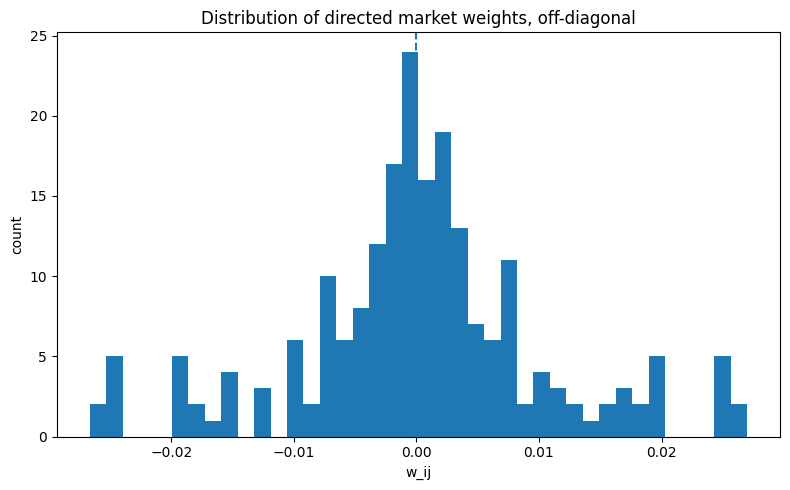

Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_weight_hist_04_05_01.png


In [11]:

plt.figure(figsize=(8, 5))
plt.hist(off_diag_weights, bins=40)
plt.axvline(0.0, linestyle="--")
plt.title("Distribution of directed market weights, off-diagonal")
plt.xlabel("w_ij")
plt.ylabel("count")
plt.tight_layout()

hist_path = OUT_DIR / "real_data_weight_hist_04_05_01.png"
plt.savefig(hist_path, dpi=160)
plt.show()
print("Saved:", hist_path)


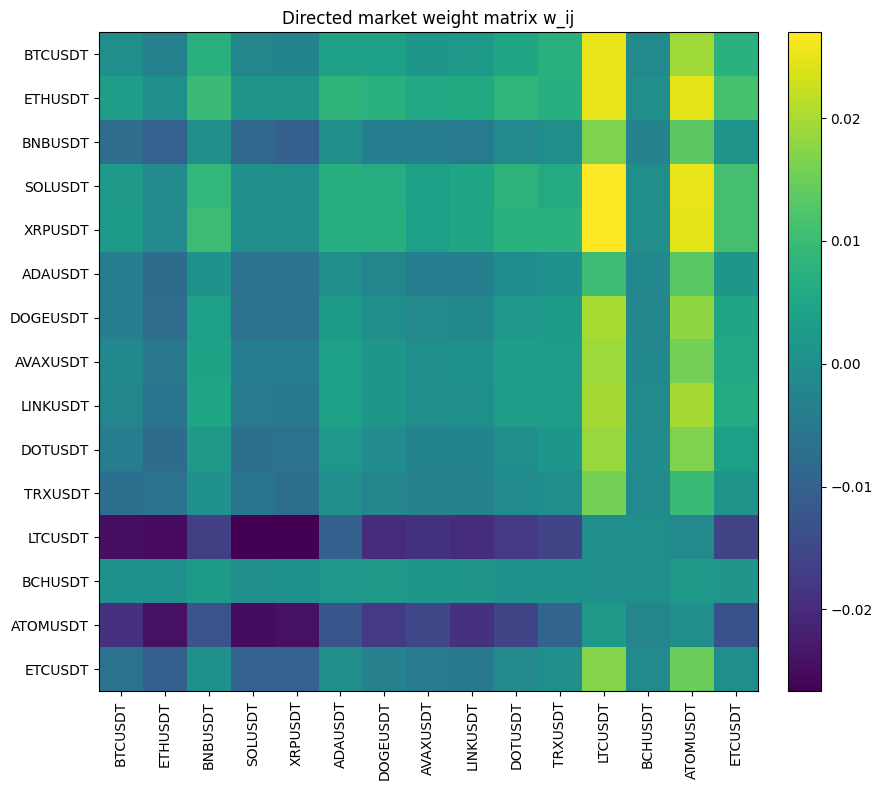

Saved: C:\Users\Антон\Desktop\курсовая\04_05\real_data_weight_heatmap_04_05_01.png


In [12]:

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(stock_w)
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(SYMBOLS, rotation=90)
ax.set_yticklabels(SYMBOLS)
ax.set_title("Directed market weight matrix w_ij")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

heatmap_path = OUT_DIR / "real_data_weight_heatmap_04_05_01.png"
plt.savefig(heatmap_path, dpi=160)
plt.show()
print("Saved:", heatmap_path)


In [13]:

print("Artifacts saved to:", OUT_DIR)
for path in sorted(OUT_DIR.glob("*04_05_01*")):
    print("-", path.name)


Artifacts saved to: C:\Users\Антон\Desktop\курсовая\04_05
- checks_04_05_01_real_market_graph.csv
- raw_binance_04_05_01
- real_data_edges_ranked_04_05_01.csv
- real_data_graph_diagnostics_04_05_01.csv
- real_data_market_weights_04_05_01.csv
- real_data_quotes_04_05_01.csv
- real_data_similarity_04_05_01.csv
- real_data_top_negative_edges_04_05_01.csv
- real_data_weight_heatmap_04_05_01.png
- real_data_weight_hist_04_05_01.png
